In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the classic Iris dataset
data = load_iris()
X = data.data
y = data.target

# Standardize
X_scaled = StandardScaler().fit_transform(X)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [3]:
# PCA -> 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.72962445 0.22850762]


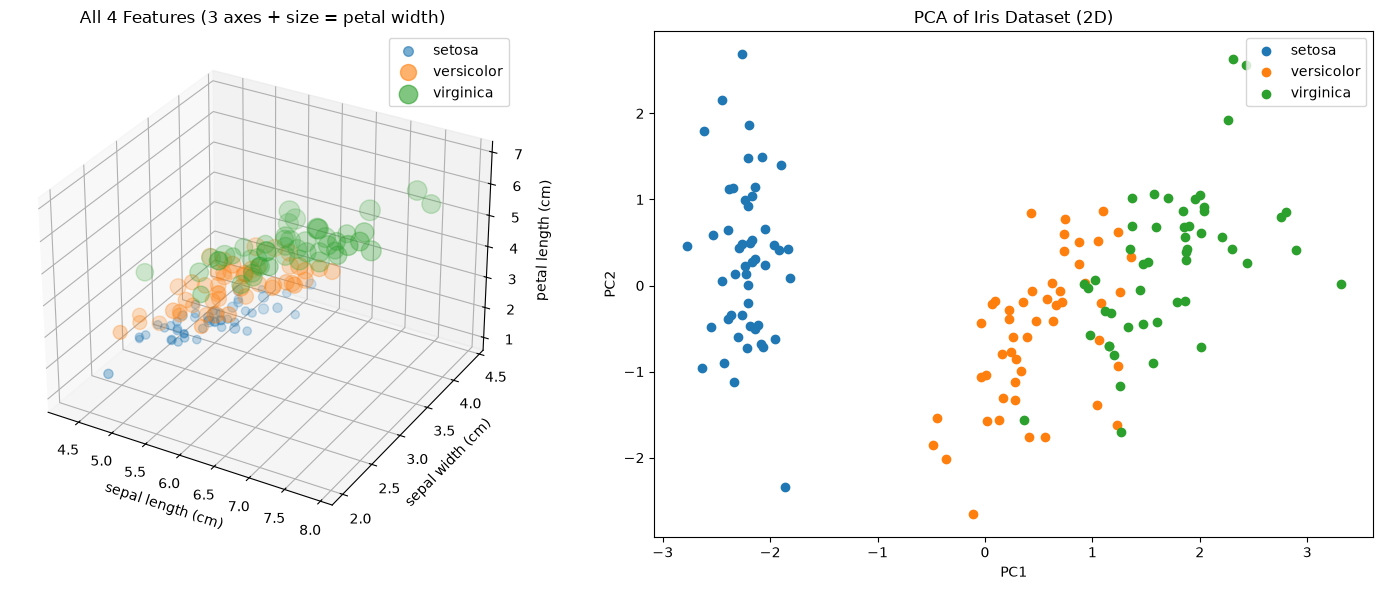

In [4]:
# Figure with two panels side by side
fig = plt.figure(figsize=(15, 6))

# --- Left: all 4 raw features in one plot ---
# 3 features -> x, y, z axes; 4th feature (petal width) -> marker size
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
sizes = 20 + (X[:, 3] / X[:, 3].max()) * 200  # petal width -> point size
for label in [0, 1, 2]:
    mask = y == label
    ax1.scatter(
        X[mask, 0],  # sepal length
        X[mask, 1],  # sepal width
        X[mask, 2],  # petal length
        s=sizes[mask],
        alpha=0.6,
        label=data.target_names[label]
    )
ax1.set_xlabel(data.feature_names[0])
ax1.set_ylabel(data.feature_names[1])
ax1.set_zlabel(data.feature_names[2])
ax1.legend()
ax1.set_title("All 4 Features (3 axes + size = petal width)")

# --- Right: 2D PCA projection ---
ax2 = fig.add_subplot(1, 2, 2)
for label in [0, 1, 2]:
    ax2.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=data.target_names[label]
    )
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend()
ax2.set_title("PCA of Iris Dataset (2D)")

plt.tight_layout()
plt.show()